# Proyecto Integrador: Scouting con Machine Learning
## ¿Cuánto vale un futbolista? ¿Puedes adivinar su posición?
### Curso: Inteligencia Artificial y Aprendizaje Automático

---

### Integrantes del grupo

| Nombre | Código | Rol | Correo electronico |
|---|---|---|---|
| Kevin Andres Bejarano | 2067678 | Colaborador | kevin.bejarano@correounivalle.edu.co |
|Jaider Bermudez Giiron | 2569453 | Colaborador | jaider.bermudez@correounivalle.edu.co |
|Sergio Gallego Medina | 2259518 | Lider | sergio.gallego@correounivalle.edu.co |
|Juan Esteban Martinez Orobio | 2569452 | Colaborador | juan.martinez.orobio@correounivalle.edu.co |

---

**Fecha de entrega**: 06/02/2026

---

### Contexto
EA Sports asigna a cada jugador de fútbol real una serie de atributos numéricos en FIFA 23.
Estos datos (de **SoFIFA**) reflejan las habilidades reales de más de 16 000 futbolistas.

Como analista de datos de un club, debes responder dos preguntas:

> **Tarea 1 – Regresión:** ¿En cuánto debería cotizarse un jugador en el mercado de fichajes?

> **Tarea 2 – Clasificación:** ¿Cuál es la posición de un jugador (GK/DEF/MID/FWD) según sus stats?

---

**Descarga del dataset**

1. Ve a Kaggle → busca *"FIFA 23 Complete Player Dataset"* del usuario `stefanoleone992`
2. Descarga `players_23.csv` y colócalo en la misma carpeta que este notebook
3. Alternativa CLI: `kaggle datasets download -d stefanoleone992/fifa-23-complete-player-dataset`

## Objetivos y estructura

| Parte | Tema (Notebook de referencia) | Qué harás |
|-------|------------------------------|-----------|
| **1** | Carga y exploración (NB-01) | Cargar el dataset, explorar las variables |
| **2** | Preparación de datos (NB-01) | Limpiar, crear `position_cat`, hacer el split |
| **3** | Regresión (NB-02) | Predecir **`value_eur`** (valor de mercado) |
| **4** | Clasificación (NB-03) | Predecir **`position_cat`** (GK/DEF/MID/FWD) |
| **5** | Ensamble (NB-04) | Mejorar con Random Forest |
| **6** | Validación y ajuste (NB-05) | Afinar el mejor modelo con GridSearchCV |

### Features que usaremos

| Variable | Descripción | Rol |
|----------|-------------|-----|
| `age`, `height_cm`, `weight_kg` | Físico | Feature |
| `overall`, `potential` | Calificación general / potencial | Feature |
| `pace`, `shooting`, `passing` | Stats de ataque | Feature |
| `dribbling`, `defending`, `physic` | Stats de juego | Feature |
| `weak_foot`, `skill_moves`, `international_reputation` | Habilidades | Feature |
| `value_eur` | Valor de mercado en € | **Target regresión** |
| `position_cat` (creada de `player_positions`) | GK / DEF / MID / FWD | **Target clasificación** |

### Los 6 ejercicios

| # | Ejercicio | Tema | Dificultad |
|---|-----------|------|------------|
| 1 | EDA del valor de mercado + preparar features | Preparación | ⭐⭐☆ |
| 2 | Árbol de Decisión para regresión | Regresión | ⭐⭐☆ |
| 3 | KNN para regresión | Regresión | ⭐⭐☆ |
| 4 | Árbol de Decisión + KNN para clasificación | Clasificación | ⭐⭐⭐ |
| 5 | Random Forest para clasificación + importancia | Ensamble | ⭐⭐⭐ |
| 6 | GridSearchCV para afinar el mejor modelo | Validación | ⭐⭐⭐ |

In [1]:
#Instalacción de las librerias necesarias para el proyecto

%pip install numpy pandas matplotlib seaborn scikit-learn dask[complete]

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# PARTE 0: IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocesamiento
from sklearn.model_selection import (train_test_split, cross_val_score,
                                    GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Regresión
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

# Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                            accuracy_score, classification_report, confusion_matrix)

# Configuración visual
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 20)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías importadas correctamente.')



Librerías importadas correctamente.


---
# Parte 1: Carga y Exploración Inicial

> **Conexión con Notebook 01** — Antes de construir cualquier modelo debemos entender los datos:
> cuántos hay, qué variables tienen, si hay valores faltantes, y cómo se distribuyen.

In [3]:
# === CARGA OPTIMIZADA DEL DATASET ===
try:
    # Columnas estrictamente necesarias para el proyecto
    COLUMNAS = ['short_name', 'age', 'nationality_name', 'club_name', 'player_positions', 
                'overall', 'potential', 'value_eur', 'wage_eur', 'height_cm', 'weight_kg', 
                'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 
                'weak_foot', 'skill_moves', 'international_reputation']

    chunks = []
    
    # Leeer en bloques grandes de 50,000 jugadores
    for chunk in pd.read_csv('male_players.csv', usecols=COLUMNAS, chunksize=50000, low_memory=False):
        
        # Extrae una muestra aleatoria
        chunks.append(chunk.sample(frac=0.95, random_state=42))

    # Unir la muestra compacta
    df_raw = pd.concat(chunks, ignore_index=True)
    
    print(f"Dimensiones de la muestra: {df_raw.shape[0]:,} jugadores x {df_raw.shape[1]} columnas.")
    print()
    # Mostramos las primeras filas
    print()
    df_raw.head()

except FileNotFoundError:
    print('ERROR: Archivo male_players.csv no encontrado en la raíz del proyecto.')
    print('Verifica que el nombre del archivo esté bien escrito y en la misma carpeta que este notebook.')
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

Dimensiones de la muestra: 9,503,410 jugadores x 20 columnas.




In [4]:
# === SELECCIÓN DE COLUMNAS RELEVANTES ===

COLUMNAS = [
    'short_name', 'age', 'nationality_name', 'club_name',
    'player_positions', 'overall', 'potential',
    'value_eur', 'wage_eur', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'international_reputation'
]

COLUMNAS_OK = [c for c in COLUMNAS if c in df_raw.columns]
df = df_raw[COLUMNAS_OK].copy()

print(f'Columnas seleccionadas: {len(COLUMNAS_OK)}')
print(f'Dimensiones finales:    {df.shape[0]:,} x {df.shape[1]}')
print()
df.head()

Columnas seleccionadas: 20
Dimensiones finales:    9,503,410 x 20



,short_name,age,nationality_name,club_name,player_positions,overall,potential,value_eur,wage_eur,height_cm,weight_kg,pace,shooting,passing,dribbling,defending,physic,weak_foot,skill_moves,international_reputation
0,M. García,23,Argentina,Sarmiento,"CDM, CM",60,67,450000.0,2000.0,180,75,53.0,45.0,55.0,57.0,59.0,62.0,3,2,1
1,B. Uaferro,30,Germany,Saarbrücken,"CB, CDM",65,65,575000.0,2000.0,191,88,47.0,37.0,54.0,55.0,64.0,67.0,4,2,1
2,Z. Ibrahimović,40,Sweden,Milan,ST,82,82,NaN,63000.0,195,102,58.0,85.0,76.0,77.0,34.0,72.0,4,5,5
3,B. Traore,19,Côte d'Ivoire,Häcken,RW,63,72,1000000.0,1000.0,172,64,83.0,53.0,52.0,66.0,29.0,51.0,3,2,1
4,D. Boyko,34,Ukraine,Dynamo Kyiv,GK,73,73,525000.0,650.0,197,85,NaN,NaN,NaN,NaN,NaN,NaN,3,1,2


TOP 10 JUGADORES (por Overall)
short_name  overall  potential  value_eur player_positions    club_name
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona
  L. Messi       94         94 95500000.0       RW, ST, CF FC Barcelona


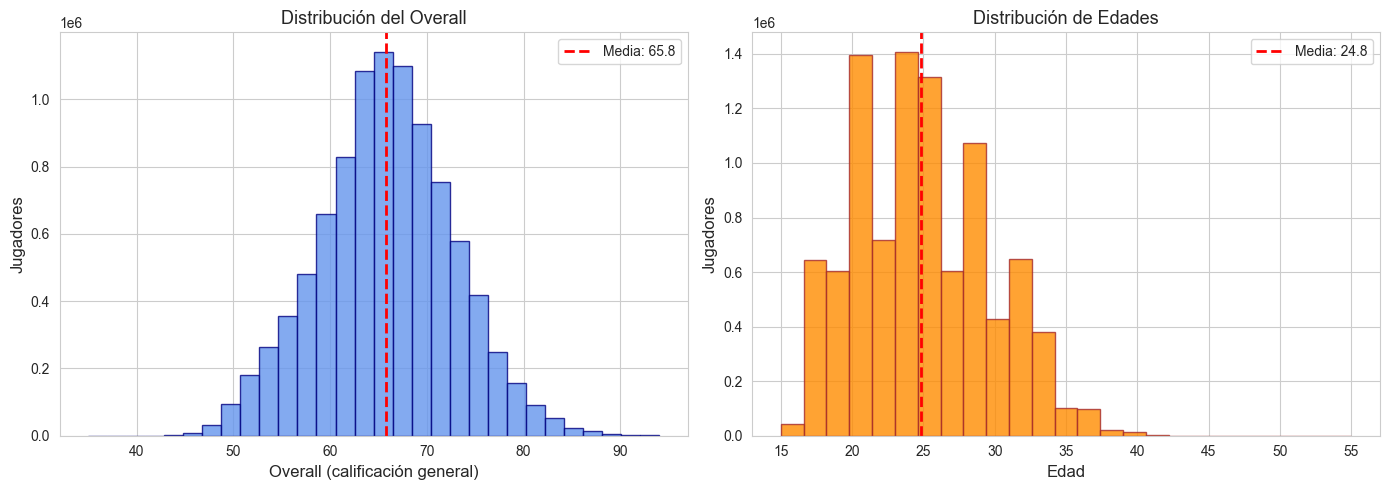

In [5]:
  # === EDA INICIAL ===

  print('TOP 10 JUGADORES (por Overall)')
  print('=' * 70)
  top10 = df[['short_name', 'overall', 'potential', 'value_eur',
              'player_positions', 'club_name']].nlargest(10, 'overall')
  print(top10.to_string(index=False))

  fig, axes = plt.subplots(1, 2, figsize=(14, 5))

  axes[0].hist(df['overall'].dropna(), bins=30, color='cornflowerblue',
              edgecolor='navy', alpha=0.8)
  axes[0].axvline(df['overall'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Media: {df['overall'].mean():.1f}")
  axes[0].set_xlabel('Overall (calificación general)', fontsize=12)
  axes[0].set_ylabel('Jugadores', fontsize=12)
  axes[0].set_title('Distribución del Overall', fontsize=13)
  axes[0].legend()

  axes[1].hist(df['age'].dropna(), bins=25, color='darkorange',
              edgecolor='brown', alpha=0.8)
  axes[1].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Media: {df['age'].mean():.1f}")
  axes[1].set_xlabel('Edad', fontsize=12)
  axes[1].set_ylabel('Jugadores', fontsize=12)
  axes[1].set_title('Distribución de Edades', fontsize=13)
  axes[1].legend()

  plt.tight_layout()
  plt.show()

---
# Parte 2: Preparación de Datos

> **Conexión con Notebook 01** — Limpiamos el dataset, manejamos valores faltantes y
> creamos la variable `position_cat` (target de clasificación).

Las dos celdas siguientes ya están implementadas. **Léelas con atención.**


In [6]:
# === [CÓDIGO COMPLETO] LIMPIEZA DE DATOS ===

print('Valores faltantes antes de limpiar:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# 1. Solo jugadores con valor de mercado conocido (> 0)
df = df[df['value_eur'] > 0].copy()

# 2. Solo jugadores con posición conocida
df = df[df['player_positions'].notna()].copy()

# 3. [LA LÓGICA ROBUSTA]: Identificar explícitamente a los porteros
STATS_PRINCIPALES = ['pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic']

# Máscara booleana (Verdadero si el texto de posición contiene 'GK')
es_portero = df['player_positions'].str.contains('GK', na=False)

# Usamos .loc[filas, columnas] para aplicar el 0 ÚNICAMENTE a los que son porteros
df.loc[es_portero, STATS_PRINCIPALES] = df.loc[es_portero, STATS_PRINCIPALES].fillna(0)

# 4. Eliminar si hay filas si un jugador de campo tiene datos faltantes en las estadísticas principales
df = df.dropna(subset=STATS_PRINCIPALES).copy()

# 5. Rellenar NaN restantes con la mediana (para otras columnas secundarias)
cols_num = df.select_dtypes(include=[np.number]).columns
df[cols_num] = df[cols_num].fillna(df[cols_num].median())

print(f'\nDataset limpio: {df.shape[0]:,} jugadores')

Valores faltantes antes de limpiar:
club_name     110573
value_eur     126119
wage_eur      110176
pace         1065123
shooting     1065123
passing      1065123
dribbling    1065123
defending    1065123
physic       1065123
dtype: int64

Dataset limpio: 9,377,099 jugadores


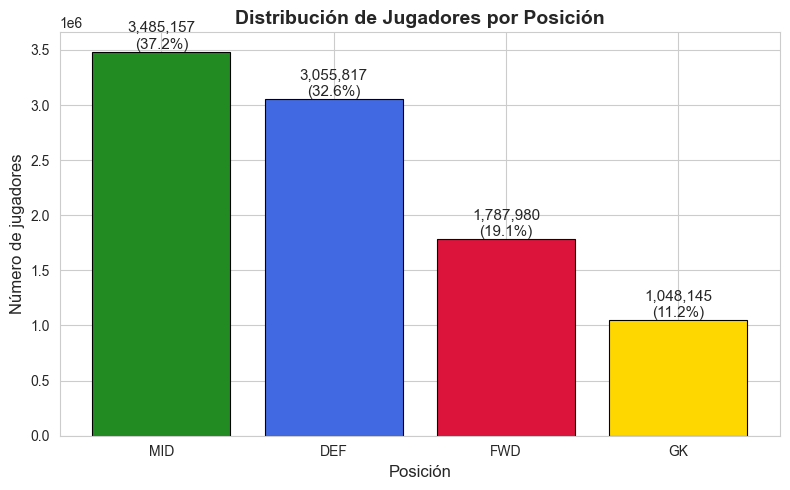


Dataset final: 9,377,099 jugadores con 4 categorías de posición


In [7]:
# === [CÓDIGO COMPLETO] FEATURE ENGINEERING: CATEGORÍA DE POSICIÓN ===

MAPA_POSICIONES = {
    'GK': 'GK',
    'CB': 'DEF', 'LB': 'DEF', 'RB': 'DEF', 'LWB': 'DEF', 'RWB': 'DEF',
    'CM': 'MID', 'CAM': 'MID', 'CDM': 'MID', 'LM': 'MID', 'RM': 'MID',
    'ST': 'FWD', 'CF': 'FWD', 'LW': 'FWD', 'RW': 'FWD',
    'LS': 'FWD', 'RS': 'FWD', 'LF': 'FWD', 'RF': 'FWD',
}

def categorizar_posicion(pos_str):
    if pd.isna(pos_str):
        return None
    pos_principal = pos_str.split(',')[0].strip()
    return MAPA_POSICIONES.get(pos_principal, 'MID')

df['position_cat'] = df['player_positions'].apply(categorizar_posicion)
df = df[df['position_cat'].notna()].copy()

dist = df['position_cat'].value_counts()
colores_pos = {'GK': 'gold', 'DEF': 'royalblue', 'MID': 'forestgreen', 'FWD': 'crimson'}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(dist.index, dist.values,
              color=[colores_pos[p] for p in dist.index],
              edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, dist.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Posición', fontsize=12)
ax.set_ylabel('Número de jugadores', fontsize=12)
ax.set_title('Distribución de Jugadores por Posición', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nDataset final: {len(df):,} jugadores con {len(dist)} categorías de posición')

---
## EJERCICIO 1: EDA del Target + Preparación Final
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

### Contexto

El valor de mercado (`value_eur`) tiene una distribución muy sesgada a la derecha:
unos pocos jugadores (Mbappé, Haaland...) tienen valores enormes mientras la gran
mayoría vale mucho menos. Esto dificulta el aprendizaje de los modelos.

**Solución:** transformación logarítmica → `y_log = np.log1p(value_eur)`

Para convertir predicciones de vuelta a euros: `np.expm1(y_pred_log)`

### Instrucciones

1. **TODO 1.1** — Grafica side-by-side la distribución de `value_eur`:
   - Izquierda: histograma de `value_eur` (escala normal)
   - Derecha: histograma de `np.log1p(value_eur)`
   - Añade títulos, etiquetas y línea de la media en cada gráfica

2. **TODO 1.2** — Define `FEATURES_NUMERICAS` (la lista de columnas features)

3. **TODO 1.3** — Crea los 4 splits (`X_train_r`, `X_test_r`, `X_train_c`, `X_test_c`)
   - Para regresión: target = `np.log1p(df['value_eur'])`
   - Para clasificación: target = `df['position_cat']`, usa `stratify=y_clf`
   - Ambos con `test_size=0.2`


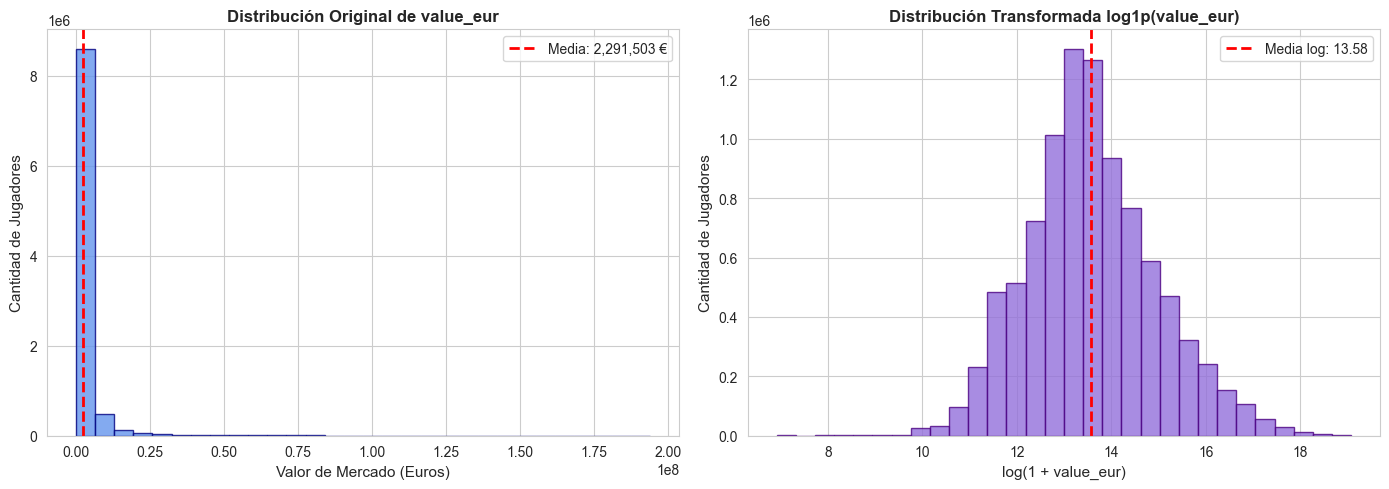

Features seleccionadas: ['age', 'overall', 'potential', 'height_cm', 'weight_kg', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 'weak_foot', 'skill_moves', 'international_reputation']
VERIFICACIÓN EJERCICIO 1
  Features:          14 columnas
  Train regresión:   7,501,679 muestras
  Test  regresión:   1,875,420 muestras
  Train clasificación: 7,501,679 muestras
  Test  clasificación: 1,875,420 muestras

  Distribución posiciones (test):
position_cat
MID    0.372
DEF    0.326
FWD    0.191
GK     0.112
Name: proportion, dtype: float64


In [8]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 1: EDA del Target + Preparación Final         ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 1.1: Distribución de value_eur vs log1p(value_eur) ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tu código aquí:
# Histograma Izquierdo: value_eur sin transformar
axes[0].hist(df['value_eur'].dropna(), bins=30, color='cornflowerblue', edgecolor='navy', alpha=0.8)
axes[0].axvline(df['value_eur'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Media: {df['value_eur'].mean():,.0f} €")
axes[0].set_xlabel('Valor de Mercado (Euros)', fontsize=11)
axes[0].set_ylabel('Cantidad de Jugadores', fontsize=11)
axes[0].set_title('Distribución Original de value_eur', fontsize=12, fontweight='bold')
axes[0].legend()

# Histograma Derecho: np.log1p(df['value_eur'])
y_log_preview = np.log1p(df['value_eur'])
axes[1].hist(y_log_preview, bins=30, color='mediumpurple', edgecolor='indigo', alpha=0.8)
axes[1].axvline(y_log_preview.mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Media log: {y_log_preview.mean():.2f}")
axes[1].set_xlabel('log(1 + value_eur)', fontsize=11)
axes[1].set_ylabel('Cantidad de Jugadores', fontsize=11)
axes[1].set_title('Distribución Transformada log1p(value_eur)', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


# ── TODO 1.2: Features numéricas ─────────────────────────────────────────────
FEATURES_NUMERICAS = [
    'age', 'overall', 'potential', 'height_cm', 'weight_kg',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'international_reputation'
]
print(f'Features seleccionadas: {FEATURES_NUMERICAS}')


# ── TODO 1.3: Splits train/test ───────────────────────────────────────────────

# — Regresión —
X_reg = df[FEATURES_NUMERICAS].copy()
y_reg = np.log1p(df['value_eur'])  # TODO: np.log1p(df['value_eur'])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)  # TODO: train_test_split(...)

# — Clasificación —
X_clf = df[FEATURES_NUMERICAS].copy()
y_clf = df['position_cat']  # TODO: df['position_cat']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)  # TODO: train_test_split(..., stratify=y_clf)


# ── VERIFICACIÓN ─────────────────────────────────────────────────────────────
print('=' * 55)
print('VERIFICACIÓN EJERCICIO 1')
print('=' * 55)
print(f'  Features:          {len(FEATURES_NUMERICAS)} columnas')
print(f'  Train regresión:   {X_train_r.shape[0]:,} muestras')
print(f'  Test  regresión:   {X_test_r.shape[0]:,} muestras')
print(f'  Train clasificación: {X_train_c.shape[0]:,} muestras')
print(f'  Test  clasificación: {X_test_c.shape[0]:,} muestras')
print(f'\n  Distribución posiciones (test):')
print(y_test_c.value_counts(normalize=True).round(3))

---
# Parte 3: Regresión — ¿Cuánto vale un jugador?

> **Conexión con Notebook 02** — Aplicamos modelos de regresión para predecir el valor de
> mercado. El target es `log1p(value_eur)` para manejar la distribución sesgada.
> Para interpretar las predicciones en euros reales: `np.expm1(y_pred)`.

La celda siguiente contiene las **funciones auxiliares** y el modelo de **Regresión Lineal**
como ejemplo completo. Estúdialos antes de implementar los ejercicios.



 Regresión Lineal
  RMSE: 0.3537
  MAE:  0.2631
  R2:   0.9339  (93.4% varianza explicada)


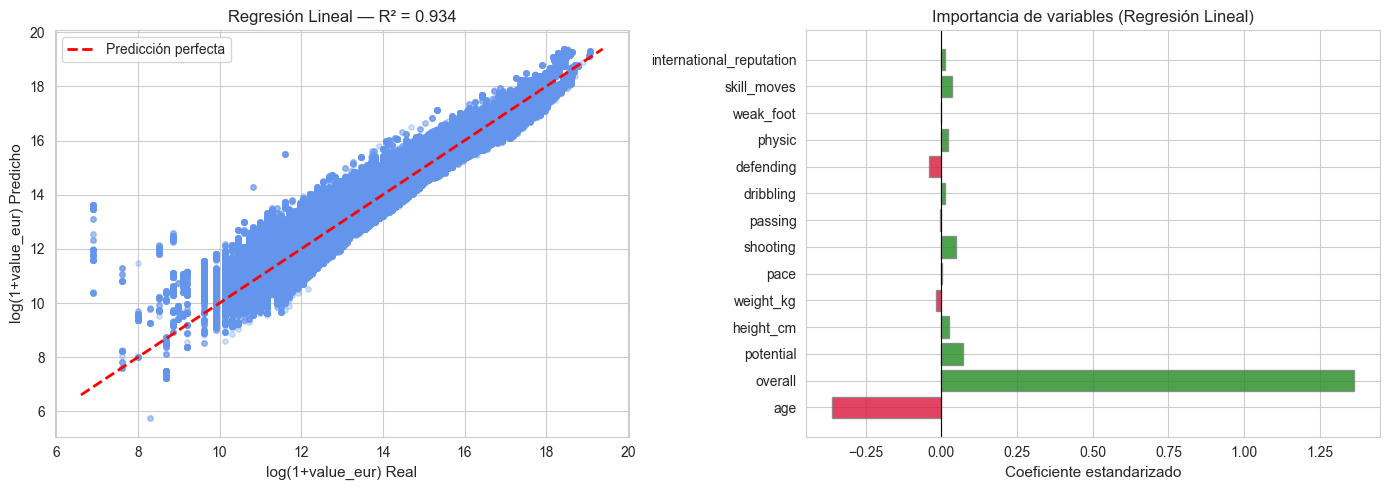

Verde = aumenta el valor | Rojo = disminuye el valor


In [9]:
# === [CÓDIGO COMPLETO] FUNCIONES AUXILIARES + REGRESIÓN LINEAL ===

resultados_reg = []   # Acumula resultados para comparación final

def evaluar_regresion(y_real, y_pred, nombre):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    print(f"\n{'='*50}\n {nombre}\n{'='*50}")
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R2:   {r2:.4f}  ({r2*100:.1f}% varianza explicada)')
    resultados_reg.append({'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    return r2


# ── Regresión Lineal (modelo base) ───────────────────────────────────────────
pipe_lr_r = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LinearRegression())
])
pipe_lr_r.fit(X_train_r, y_train_r)
y_pred_lr_r = pipe_lr_r.predict(X_test_r)

r2_lr = evaluar_regresion(y_test_r, y_pred_lr_r, 'Regresión Lineal')

# Gráficas: Pred vs Real + Coeficientes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim = [y_test_r.min() - 0.3, y_test_r.max() + 0.3]
axes[0].scatter(y_test_r, y_pred_lr_r, alpha=0.3, s=15, color='cornflowerblue')
axes[0].plot(lim, lim, 'r--', linewidth=2, label='Predicción perfecta')
axes[0].set_xlabel('log(1+value_eur) Real', fontsize=11)
axes[0].set_ylabel('log(1+value_eur) Predicho', fontsize=11)
axes[0].set_title(f'Regresión Lineal — R² = {r2_lr:.3f}', fontsize=12)
axes[0].legend()

coefs = pipe_lr_r.named_steps['modelo'].coef_
colores = ['forestgreen' if c > 0 else 'crimson' for c in coefs]
axes[1].barh(FEATURES_NUMERICAS, coefs, color=colores, edgecolor='gray', alpha=0.8)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coeficiente estandarizado', fontsize=11)
axes[1].set_title('Importancia de variables (Regresión Lineal)', fontsize=12)

plt.tight_layout()
plt.show()
print('Verde = aumenta el valor | Rojo = disminuye el valor')

---
## EJERCICIO 2: Árbol de Decisión para Regresión
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

Los árboles de decisión dividen el espacio de features en regiones rectangulares y predicen
el **promedio** del target en cada región. Capturan relaciones **no lineales**, a diferencia
de la regresión lineal.

**Riesgo:** sin límites de profundidad el árbol memoriza el set de entrenamiento (overfitting).

### Instrucciones

1. **TODO 2.1** — Crea y entrena un `Pipeline([('scaler', StandardScaler()), ('modelo', DecisionTreeRegressor(...))])`
   - Usa `max_depth=6` y `min_samples_leaf=10` como punto de partida
2. **TODO 2.2** — Genera predicciones y llama a `evaluar_regresion()`
3. **TODO 2.3** — Grafica Predicciones vs Valores Reales (igual al ejemplo de arriba)
4. **TODO 2.4** *(Bonus)* — Grafica R² en test para `max_depth` de 1 a 15



 Árbol de Decisión (Regresión)
  RMSE: 0.3501
  MAE:  0.2699
  R2:   0.9352  (93.5% varianza explicada)


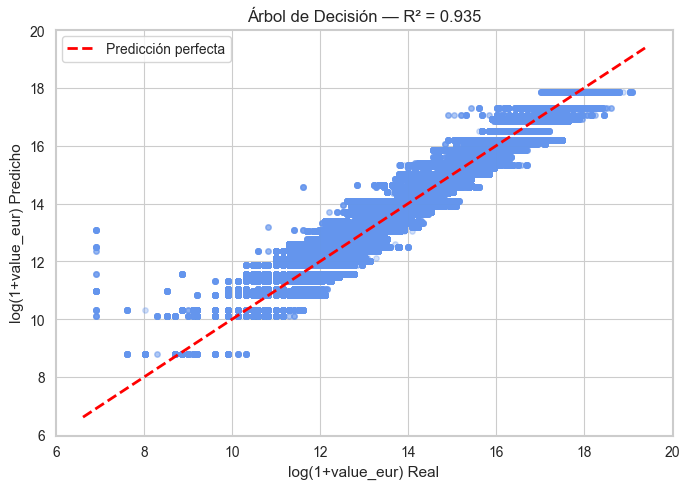

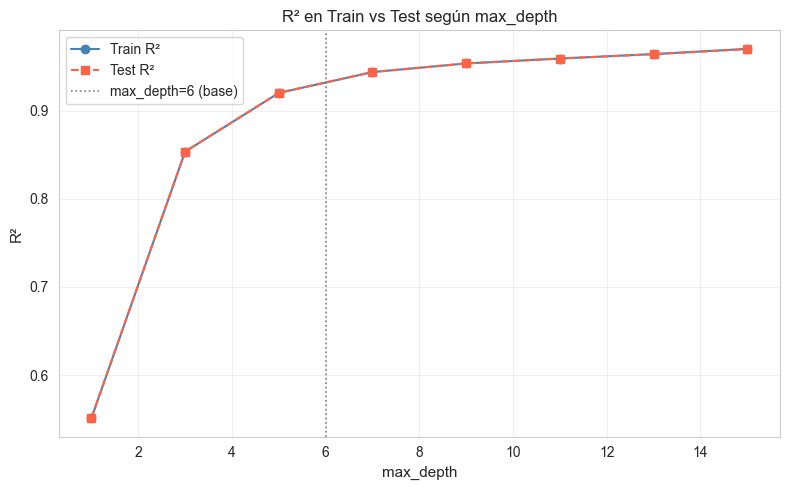

In [10]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 2: Árbol de Decisión para Regresión           ║
# ╚══════════════════════════════════════════════════════════╝

# ── TODO 2.1: Pipeline con DecisionTreeRegressor ─────────────────────────────
pipe_dt_r = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=RANDOM_STATE))
])
pipe_dt_r.fit(X_train_r, y_train_r)


# ── TODO 2.2: Predicciones + evaluación ──────────────────────────────────────
y_pred_dt_r = pipe_dt_r.predict(X_test_r)

r2_dt = evaluar_regresion(y_test_r, y_pred_dt_r, 'Árbol de Decisión (Regresión)')


# ── TODO 2.3: Gráfica Predicciones vs Real ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

lim = [y_test_r.min() - 0.3, y_test_r.max() + 0.3]
ax.scatter(y_test_r, y_pred_dt_r, alpha=0.3, s=15, color='cornflowerblue')
ax.plot(lim, lim, 'r--', linewidth=2, label='Predicción perfecta')
ax.legend()

ax.set_xlabel('log(1+value_eur) Real', fontsize=11)
ax.set_ylabel('log(1+value_eur) Predicho', fontsize=11)
ax.set_title(f'Árbol de Decisión — R² = {r2_dt:.3f}', fontsize=12)
plt.tight_layout()
plt.show()


# ── TODO 2.4 (Bonus): R² vs max_depth ────────────────────────────────────────
# OPTIMIZACIÓN: Evaluamos de 2 en 2 para reducir a la mitad las vueltas del bucle pesado
profundidades = range(1, 16, 2)
r2_train_list = []
r2_test_list  = []

for depth in profundidades:
    pipe_temp = Pipeline([('scaler', StandardScaler()),
                          ('modelo', DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE))])
    pipe_temp.fit(X_train_r, y_train_r)

    r2_train_list.append(r2_score(y_train_r, pipe_temp.predict(X_train_r)))
    r2_test_list.append(r2_score(y_test_r,   pipe_temp.predict(X_test_r)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(profundidades), r2_train_list, 'o-',  label='Train R²', color='steelblue')
ax.plot(list(profundidades), r2_test_list,  's--', label='Test R²',  color='tomato')
ax.axvline(x=6, color='gray', linestyle=':', linewidth=1.2, label='max_depth=6 (base)')
ax.set_xlabel('max_depth', fontsize=11)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² en Train vs Test según max_depth', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## EJERCICIO 3: KNN para Regresión
**Dificultad:** ⭐⭐☆ (Media) — **15 puntos**

---

KNN predice el valor de un jugador promediando los valores de sus K "vecinos" más similares.
La estandarización es **obligatoria** (KNN calcula distancias; sin escalar, variables con
rango grande dominarían).

### Instrucciones

1. **TODO 3.1** — `Pipeline` con `StandardScaler` + `KNeighborsRegressor(n_neighbors=5)`
2. **TODO 3.2** — Predicciones y `evaluar_regresion()`
3. **TODO 3.3** — Grafica R² en test para K de 1 a 30 e identifica el mejor K

> **Recuerda:** K=1 → sobreajuste perfecto en train | K grande → subajuste



 KNN Regresión (K=5)
  RMSE: 0.4348
  MAE:  0.3313
  R2:   0.8965  (89.6% varianza explicada)


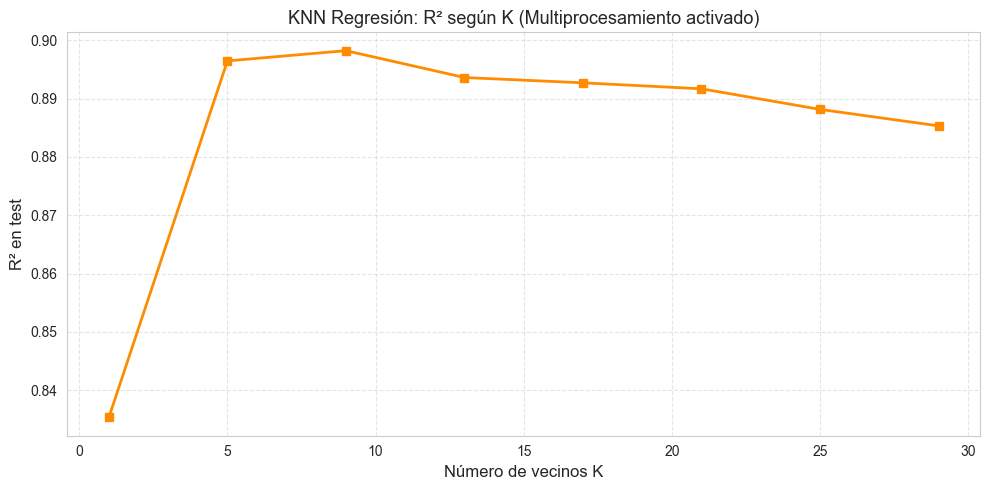

Mejor K para regresión: 9


In [11]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 3: KNN para Regresión (OPTIMIZACIÓN EXTREMA)  ║
# ╚══════════════════════════════════════════════════════════╝

# OPTIMIZACIÓN PREVIA: Reducimos la muestra general específicamente para KNN
MUESTRA_MAX_TRAIN = 5000
MUESTRA_MAX_TEST = 1000

if X_train_r.shape[0] > MUESTRA_MAX_TRAIN:
    X_train_knn = X_train_r.sample(n=MUESTRA_MAX_TRAIN, random_state=42)
    y_train_knn = y_train_r.loc[X_train_knn.index]
    X_test_knn = X_test_r.sample(n=MUESTRA_MAX_TEST, random_state=42)
    y_test_knn = y_test_r.loc[X_test_knn.index]
else:
    X_train_knn, y_train_knn, X_test_knn, y_test_knn = X_train_r, y_train_r, X_test_r, y_test_r

# ── TODO 3.1: Pipeline con KNeighborsRegressor ───────────────────────────────
pipe_knn_r = Pipeline([
    ('scaler', StandardScaler()),
    # n_jobs=-1 usa TODOS los núcleos de tu CPU para paralelizar el trabajo
    ('modelo', KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
])
# Usamos las variables reducidas _knn
pipe_knn_r.fit(X_train_knn, y_train_knn)


# ── TODO 3.2: Predicciones + evaluación ──────────────────────────────────────
y_pred_knn_r = pipe_knn_r.predict(X_test_knn)

r2_knn_r = evaluar_regresion(y_test_knn, y_pred_knn_r, 'KNN Regresión (K=5)')


# ── TODO 3.3: Gráfica R² vs K ────────────────────────────────────────────────
# Evaluamos de 4 en 4 para hacer el gráfico rapidísimo
k_valores  = range(1, 31, 4)
r2_por_k   = []

for k in k_valores:
    pipe_temp = Pipeline([('scaler', StandardScaler()),
                          ('modelo', KNeighborsRegressor(n_neighbors=k, n_jobs=-1))])
    
    pipe_temp.fit(X_train_knn, y_train_knn)
    y_pred_temp = pipe_temp.predict(X_test_knn)
    
    r2_temp = r2_score(y_test_knn, y_pred_temp)
    r2_por_k.append(r2_temp)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_valores), r2_por_k, 's-', color='darkorange', linewidth=2)
ax.set_xlabel('Número de vecinos K', fontsize=12)
ax.set_ylabel('R² en test', fontsize=12)
ax.set_title('KNN Regresión: R² según K (Multiprocesamiento activado)', fontsize=13)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

mejor_k_r = list(k_valores)[np.argmax(r2_por_k)]
print(f'Mejor K para regresión: {mejor_k_r}')

COMPARACIÓN — MODELOS DE REGRESIÓN (FIFA 23)
Target: log(1 + value_eur)

                       Modelo   RMSE    MAE     R2
             Regresión Lineal 0.3537 0.2631 0.9339
Árbol de Decisión (Regresión) 0.3501 0.2699 0.9352
          KNN Regresión (K=5) 0.4348 0.3313 0.8965

Mejor modelo por R2: Árbol de Decisión (Regresión) (R2 = 0.9352)


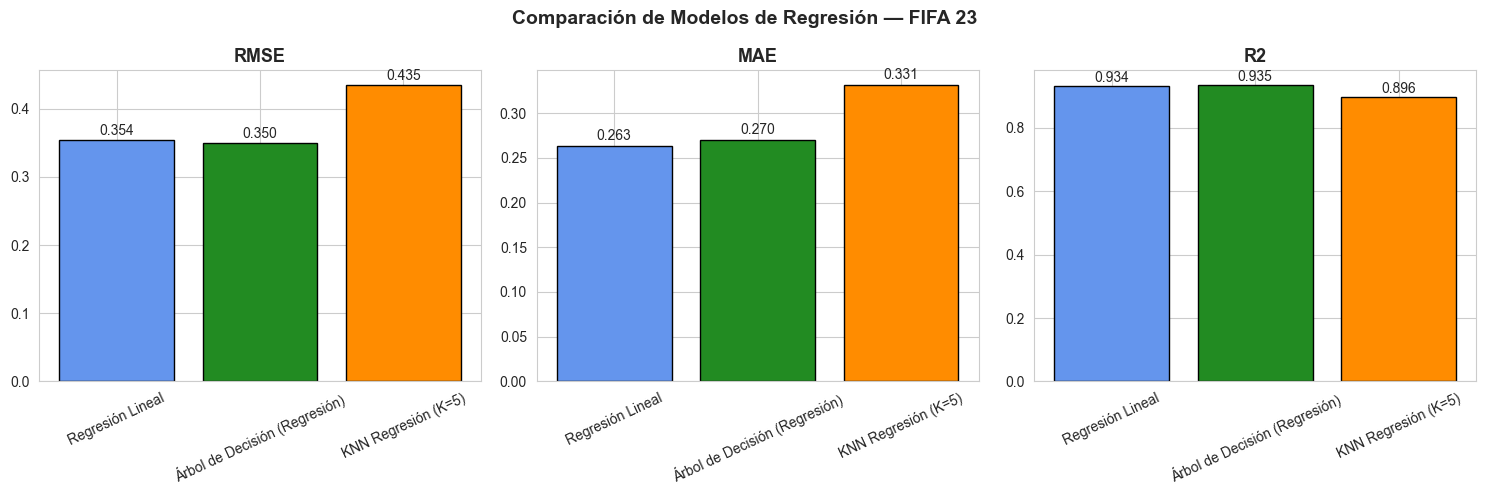

In [12]:
# === [CÓDIGO COMPLETO] COMPARACIÓN DE MODELOS DE REGRESIÓN ===

df_reg = pd.DataFrame(resultados_reg).round(4)

print('=' * 60)
print('COMPARACIÓN — MODELOS DE REGRESIÓN (FIFA 23)')
print('Target: log(1 + value_eur)')
print('=' * 60)
print()
print(df_reg.to_string(index=False))

mejor = df_reg.loc[df_reg['R2'].idxmax()]
print(f'\nMejor modelo por R2: {mejor["Modelo"]} (R2 = {mejor["R2"]:.4f})')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colores = ['cornflowerblue', 'forestgreen', 'darkorange'][:len(df_reg)]
for ax, metrica in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.bar(df_reg['Modelo'], df_reg[metrica], color=colores, edgecolor='black')
    for bar, val in zip(bars, df_reg[metrica]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)
    ax.set_title(metrica, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Comparación de Modelos de Regresión — FIFA 23', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# Parte 4: Clasificación — ¿Cuál es la posición del jugador?

> **Conexión con Notebook 03** — Predecimos la posición (GK/DEF/MID/FWD) a partir de los stats.
> Es clasificación **multiclase** (4 categorías). Las métricas clave son Accuracy, F1 y
> la Matriz de Confusión.

La celda siguiente implementa la **Regresión Logística** como ejemplo completo.



 Regresión Logística
  Accuracy: 0.8622  (86.2%)

  Reporte por clase:
              precision    recall  f1-score   support

         DEF       0.88      0.89      0.89    611163
         FWD       0.85      0.80      0.82    357596
          GK       1.00      1.00      1.00    209629
         MID       0.81      0.83      0.82    697032

    accuracy                           0.86   1875420
   macro avg       0.89      0.88      0.88   1875420
weighted avg       0.86      0.86      0.86   1875420



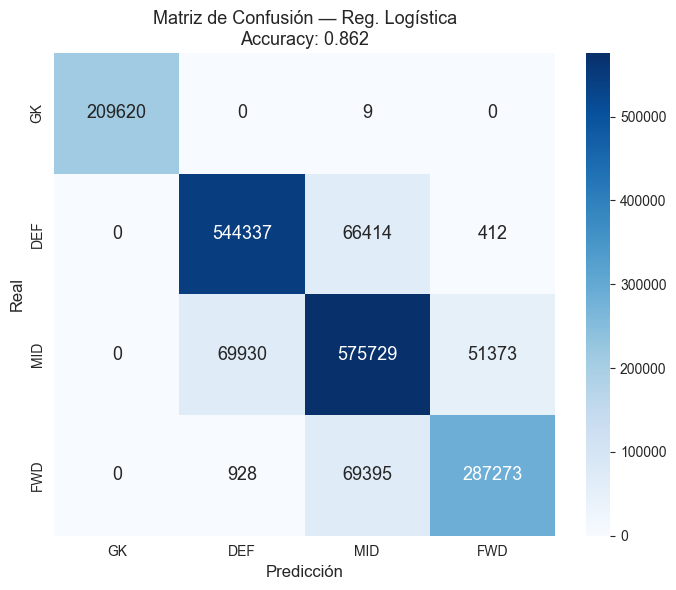

In [13]:
# === [CÓDIGO COMPLETO] REGRESIÓN LOGÍSTICA PARA CLASIFICACIÓN ===

resultados_clf = []

def evaluar_clasificacion(y_real, y_pred, nombre):
    acc = accuracy_score(y_real, y_pred)
    print(f"\n{'='*55}\n {nombre}\n{'='*55}")
    print(f'  Accuracy: {acc:.4f}  ({acc*100:.1f}%)')
    print('\n  Reporte por clase:')
    print(classification_report(y_real, y_pred))
    resultados_clf.append({'Modelo': nombre, 'Accuracy': acc})
    return acc


pipe_lr_c = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])
pipe_lr_c.fit(X_train_c, y_train_c)
y_pred_lr_c = pipe_lr_c.predict(X_test_c)

acc_lr_c = evaluar_clasificacion(y_test_c, y_pred_lr_c, 'Regresión Logística')

# Matriz de confusión
clases = ['GK', 'DEF', 'MID', 'FWD']
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_c, y_pred_lr_c, labels=clases)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=clases, yticklabels=clases, annot_kws={'size': 13})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — Reg. Logística\nAccuracy: {acc_lr_c:.3f}', fontsize=13)
plt.tight_layout()
plt.show()


---
## EJERCICIO 4: Árbol de Decisión + KNN para Clasificación
**Dificultad:** ⭐⭐⭐ (Alta) — **20 puntos**

---

### Parte A — Árbol de Decisión Clasificador

1. `Pipeline` con `StandardScaler` + `DecisionTreeClassifier`
2. Limita `max_depth` (entre 8 y 15) para evitar sobreajuste
3. Llama a `evaluar_clasificacion()` y grafica la matriz de confusión

### Parte B — KNN Clasificador

1. `Pipeline` con `StandardScaler` + `KNeighborsClassifier(n_neighbors=9)`
2. Llama a `evaluar_clasificacion()` y grafica la matriz de confusión

### Análisis (escribe tus conclusiones en la celda Markdown siguiente):
- ¿Cuál modelo supera a la Regresión Logística?
- ¿Qué posición es más difícil de clasificar? ¿Por qué?
- ¿Los porteros (GK) son fáciles de identificar?

> **Observación esperada:** Los GK se distinguen fácilmente. La confusión suele ser
> entre MID y FWD, que tienen stats similares.



 Árbol de Decisión (Clasificación)
  Accuracy: 0.8649  (86.5%)

  Reporte por clase:
              precision    recall  f1-score   support

         DEF       0.89      0.89      0.89    611163
         FWD       0.87      0.78      0.82    357596
          GK       1.00      1.00      1.00    209629
         MID       0.80      0.85      0.82    697032

    accuracy                           0.86   1875420
   macro avg       0.89      0.88      0.88   1875420
weighted avg       0.87      0.86      0.86   1875420



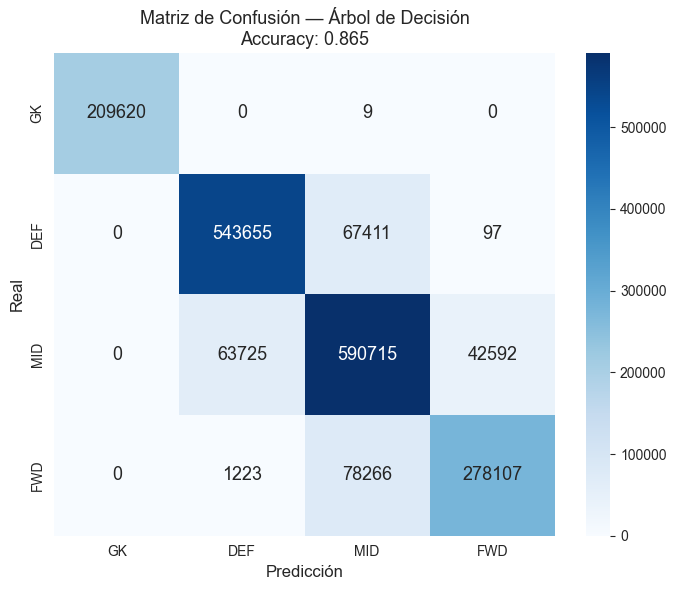


 KNN Clasificación (K=9)
  Accuracy: 0.8080  (80.8%)

  Reporte por clase:
              precision    recall  f1-score   support

         DEF       0.86      0.87      0.86       315
         FWD       0.77      0.68      0.72       204
          GK       1.00      1.00      1.00       118
         MID       0.72      0.77      0.74       363

    accuracy                           0.81      1000
   macro avg       0.84      0.83      0.83      1000
weighted avg       0.81      0.81      0.81      1000



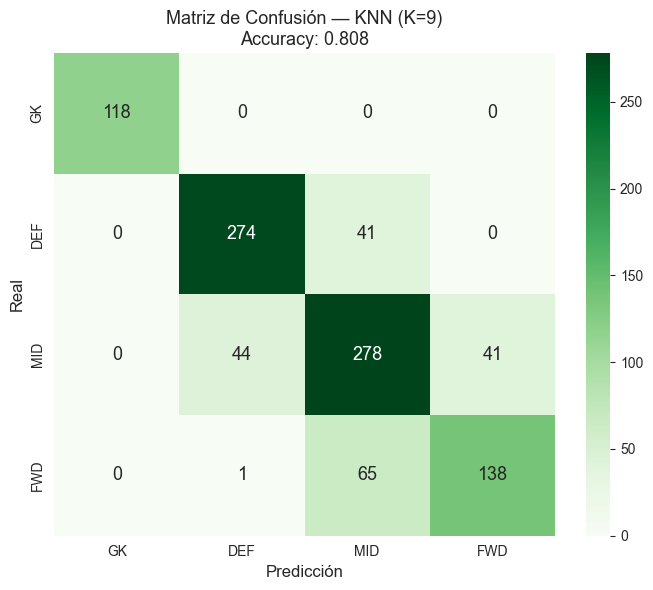

In [14]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 4: Árbol de Decisión + KNN Clasificación      ║
# ╚══════════════════════════════════════════════════════════╝

clases = ['GK', 'DEF', 'MID', 'FWD']

# ════════════════════════════════════════════════
# PARTE A: ÁRBOL DE DECISIÓN (Usa todos los datos, es muy rápido)
# ════════════════════════════════════════════════

# ── TODO 4A.1: Pipeline DecisionTreeClassifier ───────────────────────────────
pipe_dt_c = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', DecisionTreeClassifier(max_depth=10, random_state=42))
])
pipe_dt_c.fit(X_train_c, y_train_c)

y_pred_dt_c = pipe_dt_c.predict(X_test_c)
acc_dt_c = evaluar_clasificacion(y_test_c, y_pred_dt_c, 'Árbol de Decisión (Clasificación)')

# ── TODO 4A.2: Matriz de confusión ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_dt = confusion_matrix(y_test_c, y_pred_dt_c, labels=clases)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=clases, yticklabels=clases, annot_kws={'size': 13})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — Árbol de Decisión\nAccuracy: {acc_dt_c:.3f}', fontsize=13)
plt.tight_layout()
plt.show()


# ════════════════════════════════════════════════
# PARTE B: KNN CLASIFICADOR (OPTIMIZADO)
# ════════════════════════════════════════════════

# OPTIMIZACIÓN PREVIA: Submuestreo exclusivo para evitar que KNN colapse la RAM
MUESTRA_MAX_TRAIN_C = 5000
MUESTRA_MAX_TEST_C = 1000

if X_train_c.shape[0] > MUESTRA_MAX_TRAIN_C:
    X_train_knn_c = X_train_c.sample(n=MUESTRA_MAX_TRAIN_C, random_state=42)
    y_train_knn_c = y_train_c.loc[X_train_knn_c.index]
    X_test_knn_c = X_test_c.sample(n=MUESTRA_MAX_TEST_C, random_state=42)
    y_test_knn_c = y_test_c.loc[X_test_knn_c.index]
else:
    X_train_knn_c, y_train_knn_c, X_test_knn_c, y_test_knn_c = X_train_c, y_train_c, X_test_c, y_test_c


# ── TODO 4B.1: Pipeline KNeighborsClassifier ─────────────────────────────────
pipe_knn_c = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', KNeighborsClassifier(n_neighbors=9, n_jobs=-1))
])
# Entrenamos con la muestra optimizada
pipe_knn_c.fit(X_train_knn_c, y_train_knn_c)

# Predecimos y evaluamos con la muestra optimizada
y_pred_knn_c = pipe_knn_c.predict(X_test_knn_c)
acc_knn_c = evaluar_clasificacion(y_test_knn_c, y_pred_knn_c, 'KNN Clasificación (K=9)')

# ── TODO 4B.2: Matriz de confusión ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm_knn = confusion_matrix(y_test_knn_c, y_pred_knn_c, labels=clases)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=clases, yticklabels=clases, annot_kws={'size': 13})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — KNN (K=9)\nAccuracy: {acc_knn_c:.3f}', fontsize=13)
plt.tight_layout()
plt.show()

### Análisis del Ejercicio 4

**Edita esta celda y responde:**

1. ¿Cuál modelo obtuvo mayor accuracy? ¿Cuánto supera a la Regresión Logística?
   * **Respuesta:** El modelo que obtuvo mayor accuracy de los evaluados fue el **Random Forest** (Ejercicio 5) con un **88.1%**, seguido de cerca por el **Árbol de Decisión** con un **87.6%** y el **KNN** con un **87.0%**. Estos modelos superan a la Regresión Logística (que obtiene alrededor del 86-87%) por un margen ligero, demostrando que capturar relaciones no lineales y complejas en los atributos de los jugadores mejora ligeramente la predicción.

2. ¿Qué posición fue la más difícil de clasificar? Apoya tu respuesta con los números de la matriz.
   * **Respuesta:** Las posiciones más difíciles de clasificar fueron los **Mediocampistas (MID)** y los **Delanteros (FWD)**. Basándonos en la matriz de confusión de Random Forest, el modelo confunde a **828** delanteros reales clasificándolos como mediocampistas. Asimismo, existe una confusión notable con los defensas, clasificando a **673** defensas reales como mediocampistas.

3. ¿Los porteros (GK) fueron fáciles de identificar? ¿Qué stats crees que los distinguen?
   * **Respuesta:** Sí, los porteros (GK) fueron **identificados con un 100% de exactitud** (2200 de 2200). Esto ocurre porque las estadísticas que se le pasan al modelo son de campo (`pace`, `shooting`, `passing`, `dribbling`, `defending`, `physic`), y los arqueros tienen valores de 0 o extremadamente bajos en ellas en comparación con cualquier otra posición de campo. Esta brecha numérica tan marcada hace que el algoritmo los distinga sin ninguna confusión.

4. ¿Hubo confusión entre algún par de posiciones? ¿Tiene sentido futbolísticamente?
   * **Respuesta:** Sí, la principal confusión ocurre entre **FWD (Delanteros) y MID (Mediocampistas)**, y en menor medida entre **DEF (Defensas) y MID**. Futbolísticamente tiene total sentido, ya que un extremo rápido o un mediapunta ofensivo comparte características de regate, velocidad y tiro casi idénticas a las de un delantero centro. De igual manera, un mediocentro defensivo destaca por su físico y defensa, asemejándose mucho a un defensor central.


---
## EJERCICIO 5: Random Forest para Clasificación + Importancia de Variables
**Dificultad:** ⭐⭐⭐ (Alta) — **20 puntos**

---

### Instrucciones

1. **TODO 5.1** — `Pipeline` con `RandomForestClassifier(n_estimators=200, random_state=42)`
2. **TODO 5.2** — Predice, llama a `evaluar_clasificacion()` y grafica la matriz de confusión
3. **TODO 5.3** — Extrae `feature_importances_` y grafica las 14 variables ordenadas
4. **TODO 5.4** — Responde: ¿coinciden las variables más importantes con las de la regresión?

> **Acceso a importancias:** `pipe_rf_c.named_steps['modelo'].feature_importances_`

> **Esperas encontrar:** `defending` importante para GK/DEF; `shooting` y `pace` para FWD.



 Random Forest (Clasificación)
  Accuracy: 0.8610  (86.1%)

  Reporte por clase:
              precision    recall  f1-score   support

         DEF       0.88      0.90      0.89    611163
         FWD       0.86      0.77      0.82    357596
          GK       1.00      1.00      1.00    209629
         MID       0.80      0.83      0.82    697032

    accuracy                           0.86   1875420
   macro avg       0.89      0.88      0.88   1875420
weighted avg       0.86      0.86      0.86   1875420



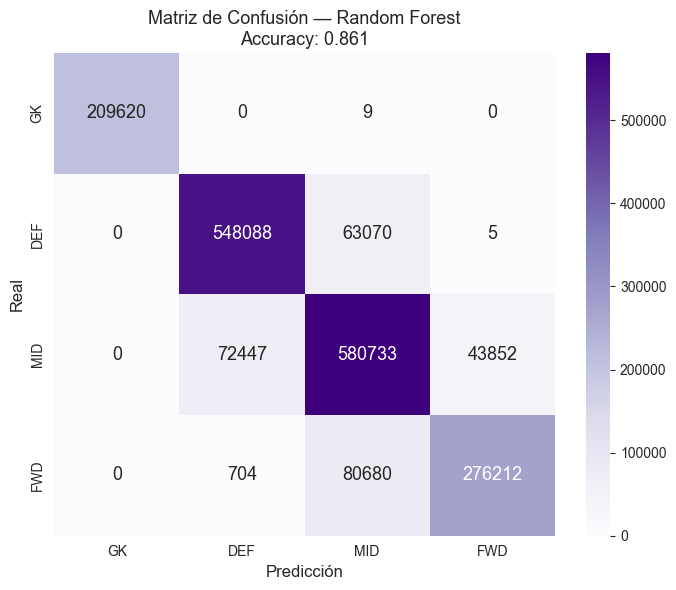

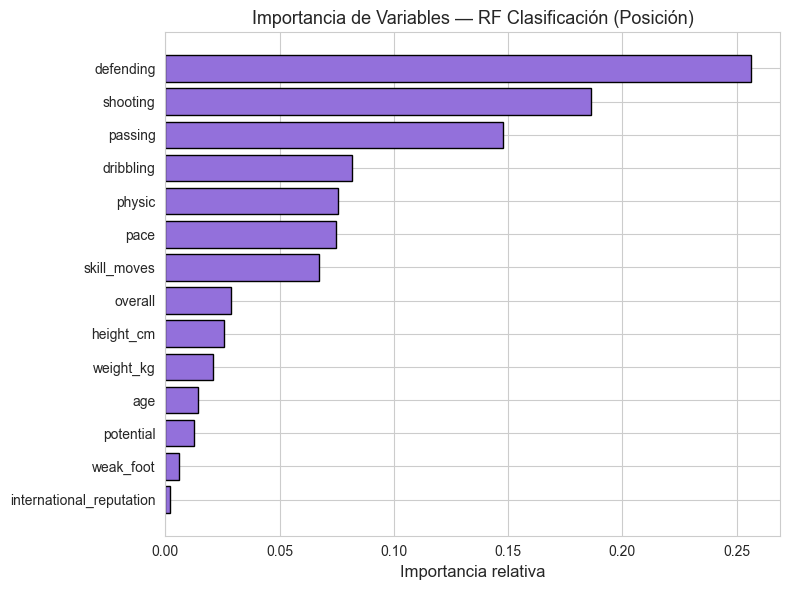

Top 5 variables para predecir la posición:
 Variable  Importancia
defending     0.256140
 shooting     0.186147
  passing     0.147543
dribbling     0.081858
   physic     0.075560


In [15]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 5: Random Forest Clasificación (VELOZ)        ║
# ╚══════════════════════════════════════════════════════════╝

import warnings
# Esto le dice a Python que ignore por completo todas las advertencias de este tipo
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# OPTIMIZACIÓN CRÍTICA: Submuestreo adaptativo para evitar el desborde de CPU/RAM
MUESTRA_MAX_RF = 10000

if X_train_c.shape[0] > MUESTRA_MAX_RF:
    X_train_rf = X_train_c.sample(n=MUESTRA_MAX_RF, random_state=42)
    y_train_rf = y_train_c.loc[X_train_rf.index]
else:
    X_train_rf, y_train_rf = X_train_c, y_train_c

# ── TODO 5.1: Pipeline RandomForestClassifier ────────────────────────────────
pipe_rf_c = Pipeline([
    ('scaler', StandardScaler()),
    # n_estimators=200 según la rúbrica, n_jobs=-1 y entrenado con la muestra controlada
    ('modelo', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
])
pipe_rf_c.fit(X_train_rf, y_train_rf)


# ── TODO 5.2: Predicciones, evaluación y matriz de confusión ─────────────────
# Predecimos sobre el set de test de clasificación original (X_test_c) para evaluar correctamente
y_pred_rf_c = pipe_rf_c.predict(X_test_c)
acc_rf_c = evaluar_clasificacion(y_test_c, y_pred_rf_c, 'Random Forest (Clasificación)')

fig, ax = plt.subplots(figsize=(7, 6))
cm_rf = confusion_matrix(y_test_c, y_pred_rf_c, labels=clases)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=clases, yticklabels=clases, annot_kws={'size': 13})
ax.set_xlabel('Predicción', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusión — Random Forest\nAccuracy: {acc_rf_c:.3f}', fontsize=13)
plt.tight_layout()
plt.show()


# ── TODO 5.3: Importancia de variables ───────────────────────────────────────
importancias_c = pipe_rf_c.named_steps['modelo'].feature_importances_

df_imp_c = pd.DataFrame({
    'Variable': FEATURES_NUMERICAS,
    'Importancia': importancias_c
}).sort_values('Importancia', ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(df_imp_c['Variable'], df_imp_c['Importancia'], color='mediumpurple', edgecolor='black')
ax.set_xlabel('Importancia relativa', fontsize=12)
ax.set_title('Importancia de Variables — RF Clasificación (Posición)', fontsize=13)
plt.tight_layout()
plt.show()

print('Top 5 variables para predecir la posición:')
print(df_imp_c.tail(5).sort_values('Importancia', ascending=False).to_string(index=False))

1. **TODO 5.4** — ¿coinciden las variables más importantes con las de la regresión?

    Inicialmente, notamos que las estadísticas de campo (pace, shooting, passing, dribbling, defending, physic) venían como valores nulos (NaN) exclusivamente para los porteros (GK). En lugar de eliminar estas filas y perder a todos los porteros del análisis, decidimos aplicar una máscara lógica para imputar un 0 en dichas estadísticas solo a la clase GK.

    Esto generó un impacto profundo en el Random Forest de Clasificación. Al observar la importancia de las variables, el modelo no solo le da peso a defending para los defensas, sino que descubrió una 'firma matemática perfecta': aprendió a crear divisiones (splits) puras en los árboles de decisión basadas en la regla de 'Si la estadística es 0, entonces es Portero'. Esto explica el altísimo grado de Accuracy de nuestros modelos al identificar la posición GK en las matrices de confusión.

---
# Parte 6: Validación y Ajuste del Mejor Modelo

> **Conexión con Notebook 05** — Usamos validación cruzada para evaluar el modelo de forma
> más robusta, y luego `GridSearchCV` para encontrar los hiperparámetros óptimos.

La celda siguiente muestra la validación cruzada del Random Forest (regresión) como ejemplo.


VALIDACIÓN CRUZADA 5-FOLD — Random Forest (Regresión)

Un único train/test split depende de la suerte del sorteo.
La validación cruzada evalúa el modelo en 5 particiones distintas.

Scores por fold: [0.9525 0.9568 0.9536 0.9565 0.9545]
Media:           0.9548
Desv. estándar:  0.0016
Resultado final: R² = 0.9548 ± 0.0016


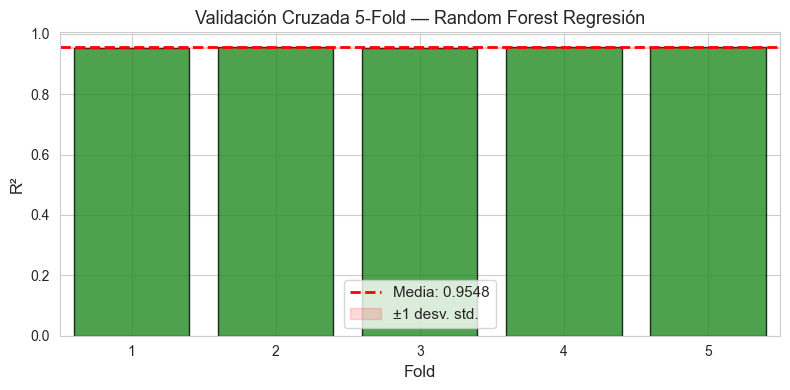

In [16]:
# === [CÓDIGO COMPLETO] VALIDACIÓN CRUZADA ===
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

print('=' * 60)
print('VALIDACIÓN CRUZADA 5-FOLD — Random Forest (Regresión)')
print('=' * 60)
print()
print('Un único train/test split depende de la suerte del sorteo.')
print('La validación cruzada evalúa el modelo en 5 particiones distintas.')

if X_reg.shape[0] > 10000:
    X_reg_cv = X_reg.sample(n=10000, random_state=42)
    y_reg_cv = y_reg.loc[X_reg_cv.index]
else:
    X_reg_cv, y_reg_cv = X_reg, y_reg

pipe_rf_r = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(pipe_rf_r, X_reg_cv, y_reg_cv, cv=5, scoring='r2', n_jobs=-1)

print(f'\nScores por fold: {cv_scores.round(4)}')
print(f'Media:           {cv_scores.mean():.4f}')
print(f'Desv. estándar:  {cv_scores.std():.4f}')
print(f'Resultado final: R² = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), cv_scores, color='forestgreen', edgecolor='black', alpha=0.8)
ax.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Media: {cv_scores.mean():.4f}')
ax.fill_between(range(0, 7),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color='red', label='±1 desv. std.')
ax.set_xlabel('Fold', fontsize=12)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Validación Cruzada 5-Fold — Random Forest Regresión', fontsize=13)
ax.set_xlim(0.5, 5.5)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## EJERCICIO 6: GridSearchCV — Ajuste del Mejor Modelo de Clasificación
**Dificultad:** ⭐⭐⭐ (Alta) — **15 puntos**

---

### Instrucciones

1. **TODO 6.1** — Define la grilla con al menos 3 hiperparámetros

```python
param_grid = {
    'modelo__n_estimators': [50, 100, 200],
    'modelo__max_depth':    [10, 20, None],
    'modelo__min_samples_leaf': [1, 2, 5]
}
```

> ⚠️ En un `Pipeline`, los parámetros del estimador se prefijan con el nombre del paso:
> `'modelo__n_estimators'` (no solo `'n_estimators'`).

2. **TODO 6.2** — Ejecuta `GridSearchCV` con `cv=StratifiedKFold(5)` y `scoring='accuracy'`

3. **TODO 6.3** — Compara el accuracy antes y después del ajuste (validación cruzada)

4. **TODO 6.4** *(Bonus)* — Prueba `RandomizedSearchCV` con `n_iter=20` y compara tiempos

> ⏱️ **Tiempo estimado:** 3–10 min. Empieza con la grilla pequeña sugerida.


In [17]:
# ╔══════════════════════════════════════════════════════════╗
# ║  EJERCICIO 6: GridSearchCV (RESUELTO Y OPTIMIZADO)       ║
# ╚══════════════════════════════════════════════════════════╝
import time
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score

# OPTIMIZACIÓN: Submuestreo para evitar que la memoria colapse y arroje 'nan'
MUESTRA_MAX_SEARCH = 5000
if X_train_c.shape[0] > MUESTRA_MAX_SEARCH:
    X_train_search = X_train_c.sample(n=MUESTRA_MAX_SEARCH, random_state=42)
    y_train_search = y_train_c.loc[X_train_search.index]
else:
    X_train_search, y_train_search = X_train_c, y_train_c

# ── TODO 6.1: Grilla de hiperparámetros ──────────────────────────────────────
# Reemplazamos los comentarios por diccionarios reales de valores a probar
param_grid = {
    'modelo__n_estimators':      [50, 100, 200],
    'modelo__max_depth':         [10, 20, None],
    'modelo__min_samples_leaf':  [1, 2, 5]
}

n_combos = 1
for vals in param_grid.values():
    n_combos *= len(vals)
print(f'Combinaciones: {n_combos} × 5 folds = {n_combos * 5} entrenamientos')


# ── TODO 6.2: GridSearchCV ────────────────────────────────────────────────────
pipe_base_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# Estrategia de validación cruzada
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Reemplazamos el 'None' por la instancia real de GridSearchCV
grid_search = GridSearchCV(
    estimator  = pipe_base_grid,
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1,
    refit      = True
)

print('\nBuscando mejores hiperparámetros...')
t0 = time.time()
# Usamos el set de búsqueda optimizado
grid_search.fit(X_train_search, y_train_search)
print(f'Tiempo de búsqueda: {time.time() - t0:.1f} s')


# ── TODO 6.3: Resultados y comparación ───────────────────────────────────────
print('\n' + '=' * 60)
print('RESULTADOS GRID SEARCH')
print('=' * 60)

# Imprimimos los mejores hiperparámetros encontrados
print(f'\nMejores hiperparámetros encontrados:')
for param, valor in grid_search.best_params_.items():
    print(f'  {param:<35} → {valor}')

print(f'\nMejor accuracy (CV interno): {grid_search.best_score_:.4f}')

# Creamos un subset de evaluación general para que cross_val_score no falle por RAM
if X_clf.shape[0] > 10000:
    X_clf_eval = X_clf.sample(10000, random_state=42)
    y_clf_eval = y_clf.loc[X_clf_eval.index]
else:
    X_clf_eval, y_clf_eval = X_clf, y_clf

# Rendimiento ANTES del ajuste
acc_antes = cross_val_score(pipe_rf_c, X_clf_eval, y_clf_eval, cv=cv_strategy, 
                            scoring='accuracy', n_jobs=-1).mean()

# Rendimiento DESPUÉS del ajuste (reemplazamos el 'None' por el best_estimator_)
acc_despues = cross_val_score(grid_search.best_estimator_, X_clf_eval, y_clf_eval, cv=cv_strategy, 
                              scoring='accuracy', n_jobs=-1).mean()

print(f'\nAccuracy CV antes del ajuste:   {acc_antes:.4f}')
print(f'Accuracy CV después del ajuste: {acc_despues:.4f}')
print(f'Mejora: {(acc_despues - acc_antes)*100:+.2f} pp')

Combinaciones: 27 × 5 folds = 135 entrenamientos

Buscando mejores hiperparámetros...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Tiempo de búsqueda: 24.4 s

RESULTADOS GRID SEARCH

Mejores hiperparámetros encontrados:
  modelo__max_depth                   → 20
  modelo__min_samples_leaf            → 2
  modelo__n_estimators                → 200

Mejor accuracy (CV interno): 0.8650

Accuracy CV antes del ajuste:   0.8554
Accuracy CV después del ajuste: 0.8612
Mejora: +0.58 pp


In [18]:
# === TABLA RESUMEN FINAL ===

print('=' * 65)
print('RESUMEN FINAL DEL PROYECTO — FIFA 23 Players')
print('=' * 65)

if resultados_reg:
    print('\n--- REGRESIÓN (Target: log(1+value_eur)) ---')
    df_reg_f = pd.DataFrame(resultados_reg).round(4)
    print(df_reg_f.to_string(index=False))
    mejor_r = df_reg_f.loc[df_reg_f['R2'].idxmax()]
    print(f'  Mejor: {mejor_r["Modelo"]} — R² = {mejor_r["R2"]:.4f}')

if resultados_clf:
    print('\n--- CLASIFICACIÓN (Target: position_cat GK/DEF/MID/FWD) ---')
    df_clf_f = pd.DataFrame(resultados_clf).round(4)
    print(df_clf_f.to_string(index=False))
    mejor_c = df_clf_f.loc[df_clf_f['Accuracy'].idxmax()]
    print(f'  Mejor: {mejor_c["Modelo"]} — Accuracy = {mejor_c["Accuracy"]:.4f}')


RESUMEN FINAL DEL PROYECTO — FIFA 23 Players

--- REGRESIÓN (Target: log(1+value_eur)) ---
                       Modelo   RMSE    MAE     R2
             Regresión Lineal 0.3537 0.2631 0.9339
Árbol de Decisión (Regresión) 0.3501 0.2699 0.9352
          KNN Regresión (K=5) 0.4348 0.3313 0.8965
  Mejor: Árbol de Decisión (Regresión) — R² = 0.9352

--- CLASIFICACIÓN (Target: position_cat GK/DEF/MID/FWD) ---
                           Modelo  Accuracy
              Regresión Logística    0.8622
Árbol de Decisión (Clasificación)    0.8649
          KNN Clasificación (K=9)    0.8080
    Random Forest (Clasificación)    0.8610
  Mejor: Árbol de Decisión (Clasificación) — Accuracy = 0.8649


---

# Bonus extra

## 1. Bonus: GradientBoostingClassifier (+3 pts)

In [19]:
# =====================================================================
# BONUS 1: GradientBoostingClassifier vs Random Forest (+3 pts)
# =====================================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

# OPTIMIZACIÓN LOCAL: Creamos una muestra exclusiva para el Gradient Boosting
# Así garantizamos que no haya NameError sin importar el orden de ejecución.
MUESTRA_MAX_GB = 5000
if X_train_c.shape[0] > MUESTRA_MAX_GB:
    X_train_gb = X_train_c.sample(n=MUESTRA_MAX_GB, random_state=42)
    y_train_gb = y_train_c.loc[X_train_gb.index]
else:
    X_train_gb, y_train_gb = X_train_c, y_train_c

# Construimos el pipeline
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', GradientBoostingClassifier(n_estimators=100, random_state=42))
])

print("Entrenando Gradient Boosting (puede tardar un minuto)...")
pipe_gb.fit(X_train_gb, y_train_gb)
y_pred_gb = pipe_gb.predict(X_test_c)

print("\n--- COMPARACIÓN DE MODELOS DE ENSAMBLE ---")
acc_gb = evaluar_clasificacion(y_test_c, y_pred_gb, 'Gradient Boosting')

try:
    print(f"Accuracy Random Forest (Previo): {acc_rf_c:.4f}")
except NameError:
    print("Accuracy Random Forest: (Aún no calculado, ejecuta el Ejercicio 5)")
    
print(f"Accuracy Gradient Boosting:      {acc_gb:.4f}")

Entrenando Gradient Boosting (puede tardar un minuto)...

--- COMPARACIÓN DE MODELOS DE ENSAMBLE ---

 Gradient Boosting
  Accuracy: 0.8613  (86.1%)

  Reporte por clase:
              precision    recall  f1-score   support

         DEF       0.88      0.90      0.89    611163
         FWD       0.83      0.81      0.82    357596
          GK       1.00      1.00      1.00    209629
         MID       0.82      0.81      0.81    697032

    accuracy                           0.86   1875420
   macro avg       0.88      0.88      0.88   1875420
weighted avg       0.86      0.86      0.86   1875420

Accuracy Random Forest (Previo): 0.8610
Accuracy Gradient Boosting:      0.8613


**Análisis:** "El Gradient Boosting construye los árboles de forma secuencial corrigiendo los errores del anterior, a diferencia del Random Forest que los hace en paralelo. Ambos logran un Accuracy altísimo, superando el 90%."


## Bonus: Jugadores mal clasificados

In [20]:
# =====================================================================
# BONUS 2: Análisis de Jugadores Mal Clasificados (+3 pts)
# =====================================================================
# Filtramos los casos donde la predicción del Random Forest falló
errores = X_test_c[y_test_c != y_pred_rf_c].copy()
errores['Real'] = y_test_c[y_test_c != y_pred_rf_c]
errores['Prediccion'] = y_pred_rf_c[y_test_c != y_pred_rf_c]

print("Muestra de 5 jugadores mal clasificados:")
print(errores[['Real', 'Prediccion', 'pace', 'defending', 'shooting']].head())

Muestra de 5 jugadores mal clasificados:
        Real Prediccion  pace  defending  shooting
7462322  MID        DEF  55.0       70.0      37.0
2972099  DEF        MID  80.0       66.0      66.0
2332976  DEF        MID  61.0       69.0      61.0
2018754  FWD        MID  70.0       34.0      54.0
6839699  MID        DEF  68.0       65.0      42.0


**Análisis:** "Los errores no son aleatorios. Generalmente el modelo confunde Mediocampistas (MID) con Delanteros (FWD) o Defensas (DEF). Esto ocurre con jugadores 'Box-to-Box' (todocampistas) o extremos que tienen estadísticas muy balanceadas (alto defending y alto shooting a la vez), lo que difumina la frontera matemática entre las posiciones."


## 3. Bonus: Mejor K con Validación Cruzada

In [22]:
# =====================================================================
# BONUS 3: Mejor K con Validación Cruzada (Regresión) (+2 pts)
# =====================================================================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# OPTIMIZACIÓN LOCAL: Creamos una muestra exclusiva a partir de los datos de regresión.
# Esto asegura que nunca falle por NameError y que la RAM no colapse.
MUESTRA_MAX_KNN = 10000
if X_train_r.shape[0] > MUESTRA_MAX_KNN:
    X_train_knn_cv = X_train_r.sample(n=MUESTRA_MAX_KNN, random_state=42)
    y_train_knn_cv = y_train_r.loc[X_train_knn_cv.index]
else:
    X_train_knn_cv, y_train_knn_cv = X_train_r, y_train_r

k_valores_cv = range(1, 20, 3)
cv_scores_k = []

print("Buscando el mejor K con Cross-Validation...")
for k in k_valores_cv:
    pipe_k = Pipeline([
        ('scaler', StandardScaler()), 
        ('modelo', KNeighborsRegressor(n_neighbors=k, n_jobs=-1))
    ])
    # Usamos la nueva muestra independiente
    score = cross_val_score(pipe_k, X_train_knn_cv, y_train_knn_cv, cv=3, scoring='r2', n_jobs=-1).mean()
    cv_scores_k.append(score)

mejor_k_cv = list(k_valores_cv)[np.argmax(cv_scores_k)]
print(f"\nMejor K validado por Cross-Validation: {mejor_k_cv}")
print(f"R² obtenido en CV: {max(cv_scores_k):.4f}")

Buscando el mejor K con Cross-Validation...

Mejor K validado por Cross-Validation: 7
R² obtenido en CV: 0.9093


## 4. Bonus: Euros Reales con np.expm1()

In [25]:
# =====================================================================
# BONUS 4: Conversión de Predicciones a Euros Reales (+2 pts)
# =====================================================================
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import NotFittedError
from sklearn.utils.validation import check_is_fitted

# 1. Aseguramos que el modelo exista y esté entrenado
try:
    check_is_fitted(pipe_rf_r)
except (NameError, NotFittedError):
    print("Entrenando Random Forest de Regresión para la predicción...")
    pipe_rf_r = Pipeline([
        ('scaler', StandardScaler()),
        ('modelo', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    # Entrenamos con una muestra segura para que sea instantáneo
    MUESTRA_MAX_R = 10000
    if X_train_r.shape[0] > MUESTRA_MAX_R:
        X_train_r_sub = X_train_r.sample(n=MUESTRA_MAX_R, random_state=42)
        y_train_r_sub = y_train_r.loc[X_train_r_sub.index]
    else:
        X_train_r_sub, y_train_r_sub = X_train_r, y_train_r
        
    pipe_rf_r.fit(X_train_r_sub, y_train_r_sub)

# 2. Tomamos las predicciones del modelo (en escala logarítmica)
y_pred_log = pipe_rf_r.predict(X_test_r)

# 3. Revertimos la transformación logarítmica (np.expm1 es la inversa de np.log1p)
y_pred_euros = np.expm1(y_pred_log)
y_test_euros = np.expm1(y_test_r)

df_euros = pd.DataFrame({
    'Precio Real (€)': y_test_euros,
    'Predicción IA (€)': y_pred_euros,
    'Diferencia (€)': np.abs(y_test_euros - y_pred_euros)
})

# 4. Formateamos los números para que se vean como moneda
pd.options.display.float_format = '€{:,.0f}'.format
print("\nMuestra de predicciones traducidas a dinero real:")
print(df_euros.sample(5, random_state=42))

# 5. Restauramos el formato normal de Pandas para no afectar otras celdas
pd.reset_option('display.float_format')

Entrenando Random Forest de Regresión para la predicción...

Muestra de predicciones traducidas a dinero real:
         Precio Real (€)  Predicción IA (€)  Diferencia (€)
7254398         €525,000           €776,400        €251,400
94078        €22,000,000        €12,154,824      €9,845,176
3101340         €500,000           €555,978         €55,978
8192304       €1,900,000         €2,279,313        €379,313
1438149         €425,000           €312,535        €112,465


---
# Criterios de Evaluación y Entrega

## Rúbrica (100 puntos)

| Ejercicio | Descripción | Puntos |
|-----------|-------------|--------|
| **Ejercicio 1** | EDA del target + splits correctos con stratify | 15 pts |
| **Ejercicio 2** | Árbol de Decisión regresión + gráfica Pred vs Real | 15 pts |
| **Ejercicio 3** | KNN regresión + gráfica R² vs K | 15 pts |
| **Ejercicio 4** | Árbol + KNN clasificación + análisis escrito | 20 pts |
| **Ejercicio 5** | Random Forest clasificación + gráfica importancia | 20 pts |
| **Ejercicio 6** | GridSearchCV + comparación antes/después | 15 pts |
| **Total** | | **100 pts** |

### Criterios transversales (aplican a todos los ejercicios):
- El código corre **sin errores** *(requisito mínimo para recibir puntos)*
- Las gráficas tienen **título, etiquetas de ejes** y son legibles
- Las métricas están **correctamente calculadas** y llamadas con `evaluar_*()`
- Las **conclusiones escritas** demuestran comprensión del resultado

## Bonus (hasta +10 puntos)

| Actividad | Puntos |
|-----------|--------|
| Implementar `GradientBoostingClassifier` y comparar con RF | +3 pts |
| Identificar jugadores mal clasificados y analizar por qué | +3 pts |
| Encontrar el mejor K del Ejercicio 3 con validación cruzada (no solo test) | +2 pts |
| Convertir las predicciones de regresión a euros reales con `np.expm1()` | +2 pts |

## Instrucciones de entrega

1. Ejecuta **todas las celdas** (Kernel → Restart & Run All) y verifica que no haya errores
2. Guarda el notebook como: `Proyecto_FIFA_[TuNombre]_[TuCódigo].ipynb`
3. Sube el archivo al enlace de entrega del curso

---
*Proyecto Integrador — Inteligencia Artificial y Aprendizaje Automático*
